# House Price Prediction using Machine Learning

In [2]:
import pandas as pd

df = pd.read_csv('/content/data.csv')

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


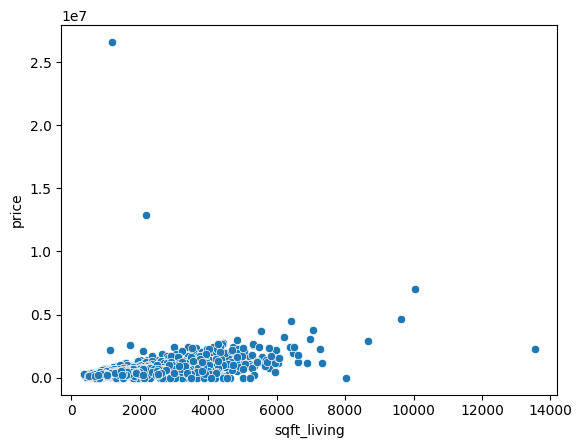

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='sqft_living',
    y='price',
    data=df
)

plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,1522,36,62,0
1,0,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,3899,35,58,0
2,0,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,2291,18,26,0
3,0,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,4263,3,7,0
4,0,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,4352,31,31,0


In [11]:
X = df.drop('price', axis=1)

y = df['price']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [14]:
lr_pred = lr.predict(X_test)

print(lr_pred[:5])

[ 316064.67583697  315217.37023819 1071220.92321244  560198.39177532
  385891.77756432]


In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test, lr_pred)

rmse = root_mean_squared_error(y_test, lr_pred)

print("Linear Regression MAE:", mae)

print("Linear Regression RMSE:", rmse)

Linear Regression MAE: 207816.82941666944
Linear Regression RMSE: 993048.5753503734


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
rf_pred = rf.predict(X_test)

print(rf_pred[:5])

[ 420117.72        313098.98333333 1129656.5         498019.3375
  253632.59857142]


In [18]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = root_mean_squared_error(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 166903.0185868121
Random Forest RMSE: 988264.8184857079


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [20]:
gb_pred = gb.predict(X_test)

print(gb_pred[:5])

[ 462764.59701941  305659.139457   1075732.04084318  465879.02076969
  283500.65281411]


In [21]:
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = root_mean_squared_error(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)

print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 170872.99415203792
Gradient Boosting RMSE: 984757.6259828946


# Model Comparison

In [22]:
print("Linear Regression RMSE:", rmse)

print("Random Forest RMSE:", rf_rmse)

print("Gradient Boosting RMSE:", gb_rmse)

Linear Regression RMSE: 993048.5753503734
Random Forest RMSE: 988264.8184857079
Gradient Boosting RMSE: 984757.6259828946


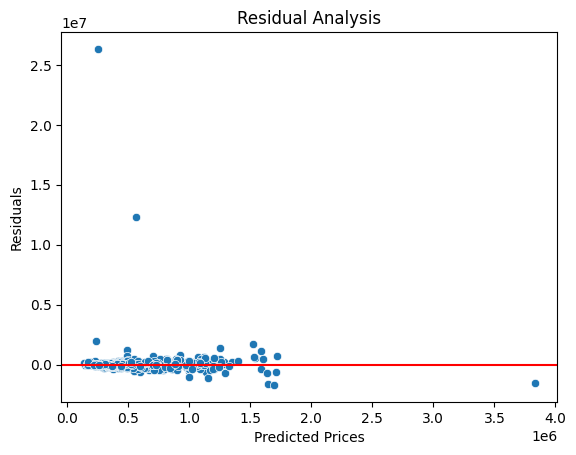

In [23]:
residuals = y_test - gb_pred

sns.scatterplot(
    x=gb_pred,
    y=residuals
)

plt.axhline(y=0, color='r')

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

In [24]:
import joblib

joblib.dump(gb, 'house_price_model.pkl')

['house_price_model.pkl']

In [25]:
model = joblib.load('house_price_model.pkl')

sample = [X_test.iloc[0].values]

prediction = model.predict(sample)

print("Predicted House Price:", prediction)

Predicted House Price: [462764.59701941]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
